In this Notebook, we visualize the merged data 

### Data Requirements:

This notebook requires the following files: 

`01_05_trips_weather_merged.parquet` — local path: `data/merged/01_05_trips_weather_merged.parquet` — Sciebo path: `data_parquet/merged/01_05_trips_weather_merged.parquet`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.

In [3]:
import pandas as pd
import numpy as np
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# reset working dir
import os
from pathlib import Path

In [4]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\Yannick Herrmann\Documents\Uni\AAA\AAA_Project\AAA_TA_2026


In [5]:
# check whether real data exists, else use sampled data
if Path("data/merged/01_05_trips_weather_merged.parquet").exists():
    df = pd.read_parquet("data/merged/01_05_trips_weather_merged.parquet")
else:
    df = pd.read_parquet("data/samples/SAMPLE_01_05_trips_weather_merged.parquet")

df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,8,8,9.75,0.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,76,6,35.00,8.1,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,8,7,55.00,0.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,22,7,11.67,4.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,8,3,17.50,0.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 39 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_community_area       int64         
 7   dropoff_community_area      int64         
 8   fare                        float64       
 9   tips                        float64       
 10  tolls                       float64       
 11  extras                      float64       
 12  trip_total                  float64       
 13  payment_type                str           
 14  company                     str           
 15  pickup_centroid_latitude    float64       
 16  pickup_centroid_longitude   f

In [7]:
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])
df["trip_start_hour"] = pd.to_datetime(df["trip_start_hour"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 39 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_community_area       int64         
 7   dropoff_community_area      int64         
 8   fare                        float64       
 9   tips                        float64       
 10  tolls                       float64       
 11  extras                      float64       
 12  trip_total                  float64       
 13  payment_type                str           
 14  company                     str           
 15  pickup_centroid_latitude    float64       
 16  pickup_centroid_longitude   f

### plot avg trip duration vs temperature:

In [9]:

df["trip_minutes"] = df["trip_seconds"] / 60

df["is_rainy"] = df["rain"] > 0

In [10]:
plot_data = df.groupby(["temperature_2m"])["trip_minutes"].mean().reset_index()


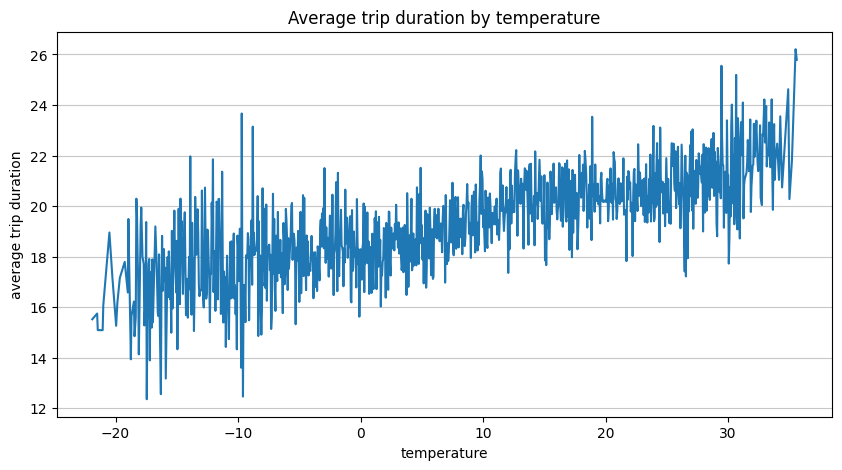

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=plot_data.sort_values("temperature_2m"),
    x="temperature_2m",
    y="trip_minutes"
)
plt.title('Average trip duration by temperature')
plt.xlabel('temperature')
plt.ylabel('average trip duration')
plt.grid(axis='y', alpha=0.7)
plt.show()

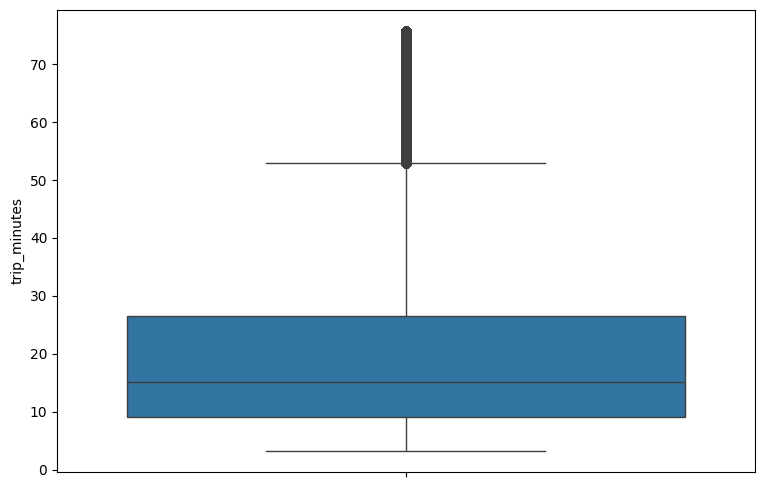

In [12]:
plt.figure(figsize=(9, 6))
sns.boxplot(df["trip_minutes"])
plt.show()

In [13]:
rainy_data = df[df["is_rainy"] == 1]
dry_data = df[df["is_rainy"] == 0]

In [14]:
rainy_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,...,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation,trip_minutes,is_rainy
38620,0491b13c113fdafb1f6e34010afec882e4d1cf9d,bbf01463df9f2c093157c6be2bd489f06fd080e89bdd06...,2025-01-05 18:00:00,2025-01-05 18:30:00,1345.0,9.87,33,14,27.25,0.00,...,0.0,990.414551,100.0,19.328011,30.502962,0.0,0.0,0.0,22.416667,True
38621,053d27d81fc04ec8fdf5ae68b14839c03822bb8a,ba87ebcada16aad3f40ed6699a9e67512f64ef670e2777...,2025-01-05 18:00:00,2025-01-05 18:00:00,754.0,1.99,32,8,9.00,0.00,...,0.0,990.414551,100.0,19.328011,30.502962,0.0,0.0,0.0,12.566667,True
38622,059de59b6c9f3157a8d7e36f6c593701f11cabf6,9290a8430ba3e8061554627a9b1ebc78fd78a446a92b55...,2025-01-05 18:00:00,2025-01-05 18:30:00,1080.0,2.70,42,68,12.50,0.00,...,0.0,990.414551,100.0,19.328011,30.502962,0.0,0.0,0.0,18.000000,True
38623,0935719a4148e9af163c0575bbb52ebbe53125c1,2f5a8b67f988625ed892f9f87d48255861bae9beaeb573...,2025-01-05 18:00:00,2025-01-05 18:30:00,1779.0,14.53,76,7,51.00,5.00,...,0.0,990.414551,100.0,19.328011,30.502962,0.0,0.0,0.0,29.650000,True
38624,0ad95c280324677f9a4f7f14274ade5971d23a2a,14b8965581705a67e75b3fadeb43570909052a0f646341...,2025-01-05 18:00:00,2025-01-05 18:30:00,1532.0,12.01,76,5,31.25,7.35,...,0.0,990.414551,100.0,19.328011,30.502962,0.0,0.0,0.0,25.533333,True


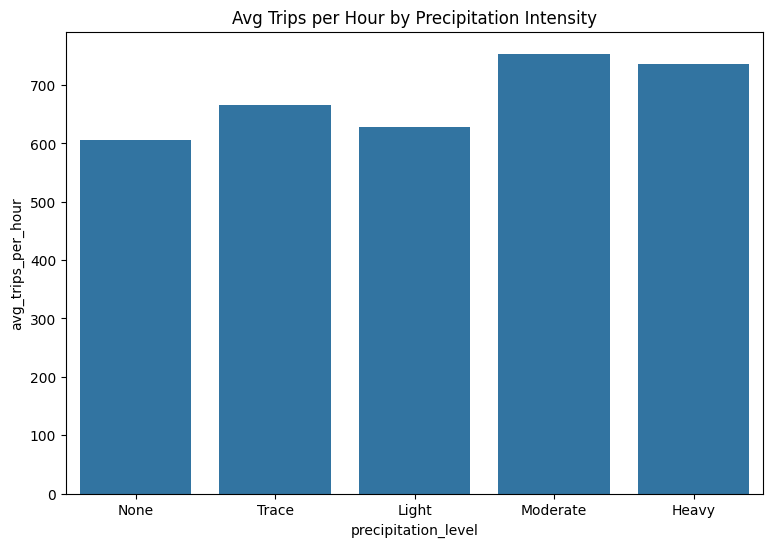

In [15]:
df['precipitation_level'] = pd.cut(
    df['precipitation'],
    bins=[-0.001, 0, 0.5, 2, 5, 100],
    labels=['None', 'Trace', 'Light', 'Moderate', 'Heavy']
)

precipitation_rate = (
    df.groupby(['precipitation_level', 'trip_start_hour'])
      .size()
      .groupby('precipitation_level')
      .mean()
      .reset_index(name='avg_trips_per_hour')
)

plt.figure(figsize=(9, 6))
sns.barplot(data = precipitation_rate, x = "precipitation_level", y="avg_trips_per_hour")
plt.title('Avg Trips per Hour by Precipitation Intensity')
plt.xticks(rotation=0)
plt.show()

In [16]:
df["start_month"] = df["trip_start_timestamp"].dt.month
df["start_hour"] = df["trip_start_timestamp"].dt.hour


Text(0.5, 0, 'Month')

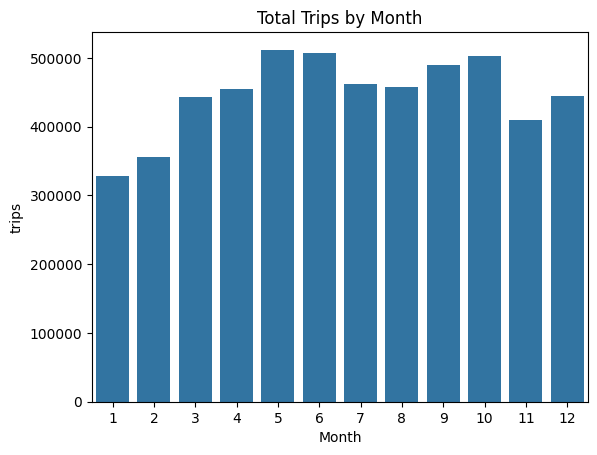

In [17]:
monthly = df.groupby('start_month').size().reset_index(name='trips')
sns.barplot(data=monthly, x='start_month', y='trips')
plt.title('Total Trips by Month')
plt.xlabel('Month')

average demand per hour, dry vs rainy:

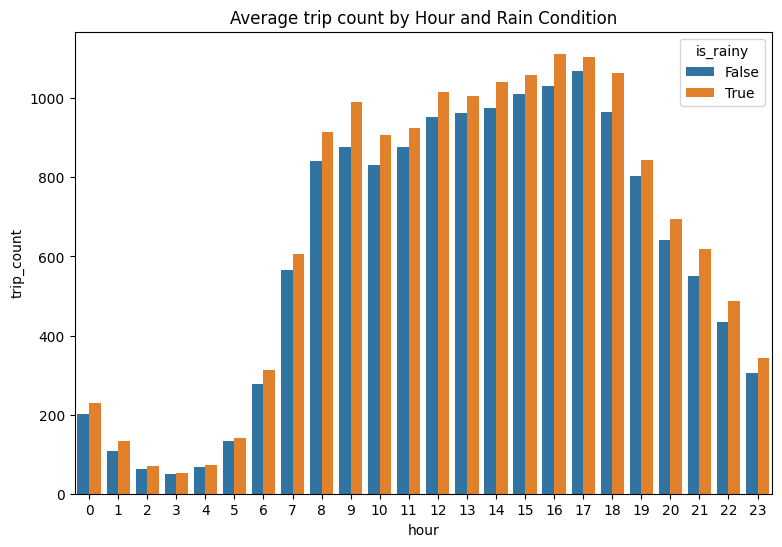

In [18]:
hourly_demand = (
    df.groupby(["trip_start_hour", "is_rainy"])
      .size()
      .reset_index(name="trip_count")
)

hourly_demand["hour"] = hourly_demand["trip_start_hour"].dt.hour

avg_demand = (
    hourly_demand.groupby(["hour", "is_rainy"])["trip_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_demand, x = "hour", y="trip_count", hue = "is_rainy")
plt.title("Average trip count by Hour and Rain Condition")
plt.show()

average trip duration per hour, dry vs rainy:

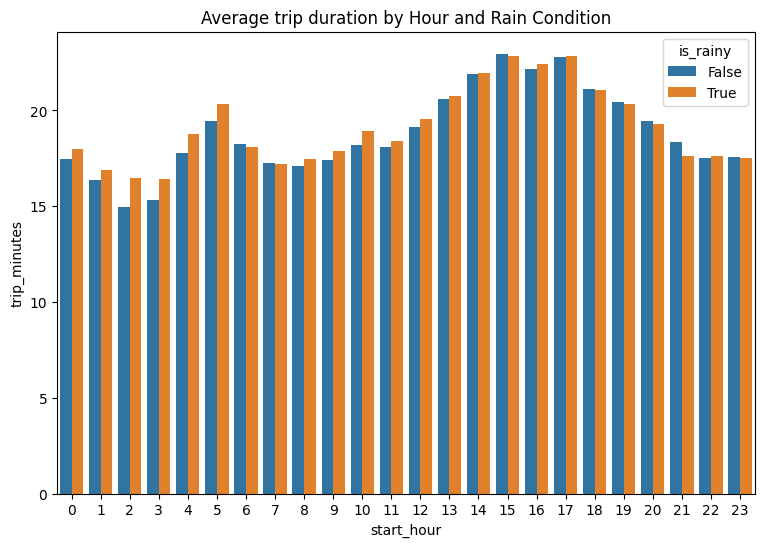

In [19]:
avg_duration = (
    df.groupby(["start_hour", "is_rainy"])["trip_minutes"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_duration, x = "start_hour", y="trip_minutes", hue = "is_rainy")
plt.title("Average trip duration by Hour and Rain Condition")
plt.show()

average trip distance per hour, dry vs rainy:

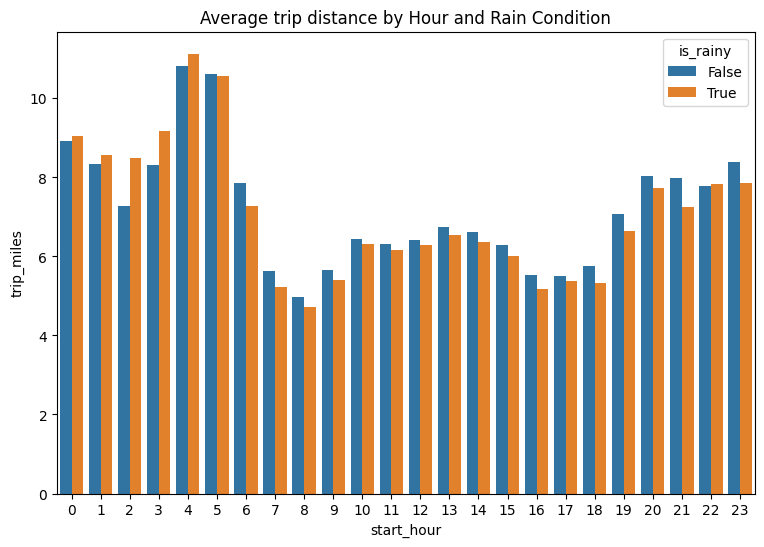

In [20]:
avg_distance = (
    df.groupby(["start_hour", "is_rainy"])["trip_miles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_distance, x = "start_hour", y="trip_miles", hue = "is_rainy")
plt.title("Average trip distance by Hour and Rain Condition")
plt.show()

average fare per mile per hour, dry vs rainy:

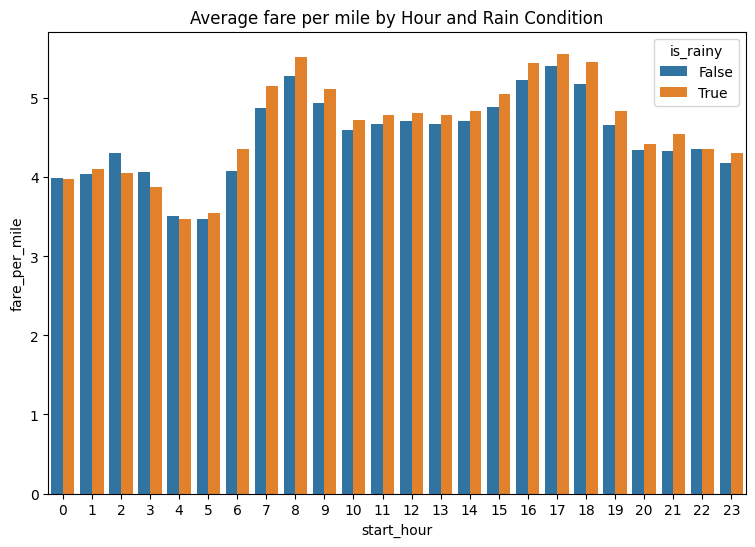

In [21]:
df['fare_per_mile'] = df['fare'] / df['trip_miles'].replace(0, np.nan)

avg_fare_per_mile = (
    df.groupby(["start_hour", "is_rainy"])["fare_per_mile"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_fare_per_mile, x = "start_hour", y="fare_per_mile", hue = "is_rainy")
plt.title("Average fare per mile by Hour and Rain Condition")
plt.show()

average tip rate per hour, dry vs rainy:

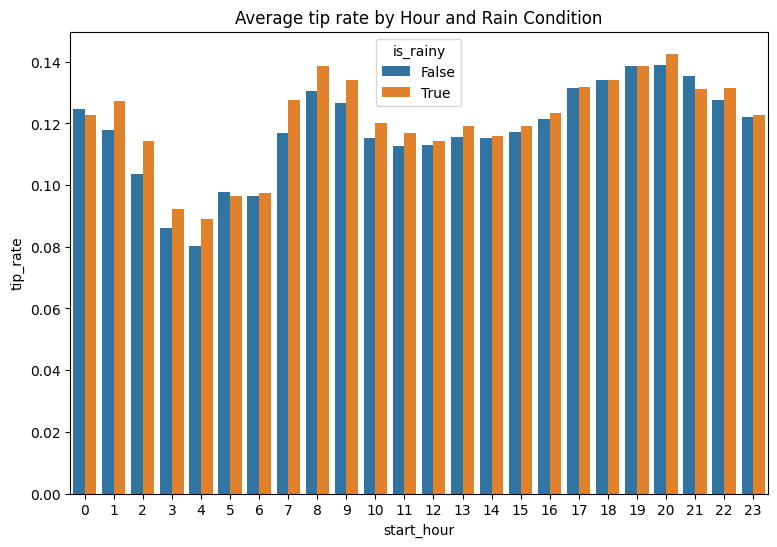

In [22]:
df['tip_rate'] = df['tips'] / df['fare']

avg_tip_rate = (
    df.groupby(["start_hour", "is_rainy"])["tip_rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_tip_rate, x = "start_hour", y="tip_rate", hue = "is_rainy")
plt.title("Average tip rate by Hour and Rain Condition")
plt.show()

average idle time per hour, dry vs rainy:

Finding the end time of each taxi's previous trip...
Calculating idle time in minutes...
 Actively cleaning and fixing data anomalies...
Dropping temporary columns to preserve RAM...
Dropped 3035 first trips (no history)
Clamped 51254 overlapping trips to 0
Removed 1317561 off-duty gaps (>120 min)


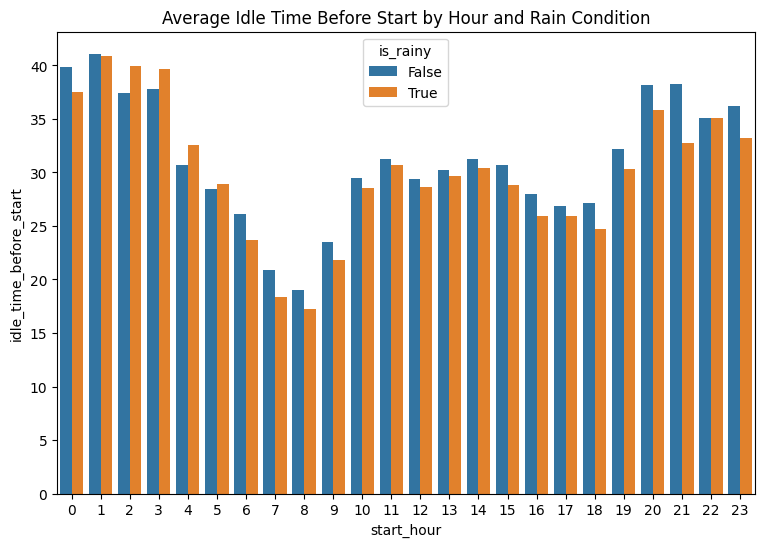

In [23]:
df_idle = df[['taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'is_rainy', 'start_hour']].copy()
df_idle = df_idle.sort_values(['taxi_id', 'trip_start_timestamp'])


print("Finding the end time of each taxi's previous trip...")
df_idle['prev_trip_end'] = df_idle.groupby('taxi_id')['trip_end_timestamp'].shift(1)

print("Calculating idle time in minutes...")
time_diff = df_idle['trip_start_timestamp'] - df_idle['prev_trip_end']
df_idle['idle_time_before_start'] = time_diff.dt.total_seconds() / 60.0

print(" Actively cleaning and fixing data anomalies...")

# Explicitly count and drop the first trip of every taxi since history is unknown
n_before_anomaly_a = len(df_idle)
df_idle = df_idle.dropna(subset=['idle_time_before_start']).reset_index(drop=True)
dropped_first_trips = n_before_anomaly_a - len(df_idle)

# Overlapping trips: force negative idle times to 0 minutes
overlap_count = (df_idle['idle_time_before_start'] < 0).sum()
df_idle.loc[df_idle['idle_time_before_start'] < 0, 'idle_time_before_start'] = 0

# Off-duty shifts: If a gap is > 2 hours, it's a break. Set to NaN so it doesn't pollute averages.
break_count = (df_idle['idle_time_before_start'] > 120).sum()
df_idle.loc[df_idle['idle_time_before_start'] > 120, 'idle_time_before_start'] = np.nan

print("Dropping temporary columns to preserve RAM...")
df_idle = df_idle.drop(columns=['prev_trip_end'])

print(f"Dropped {dropped_first_trips} first trips (no history)")
print(f"Clamped {overlap_count} overlapping trips to 0")
print(f"Removed {break_count} off-duty gaps (>120 min)")

avg_idle_time = (
    df_idle.groupby(["start_hour", "is_rainy"])["idle_time_before_start"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_idle_time, x = "start_hour", y="idle_time_before_start", hue = "is_rainy")
plt.title("Average Idle Time Before Start by Hour and Rain Condition")
plt.show()

Text(0.5, 1.0, 'Average Hourly Demand: Weekday vs Weekend')

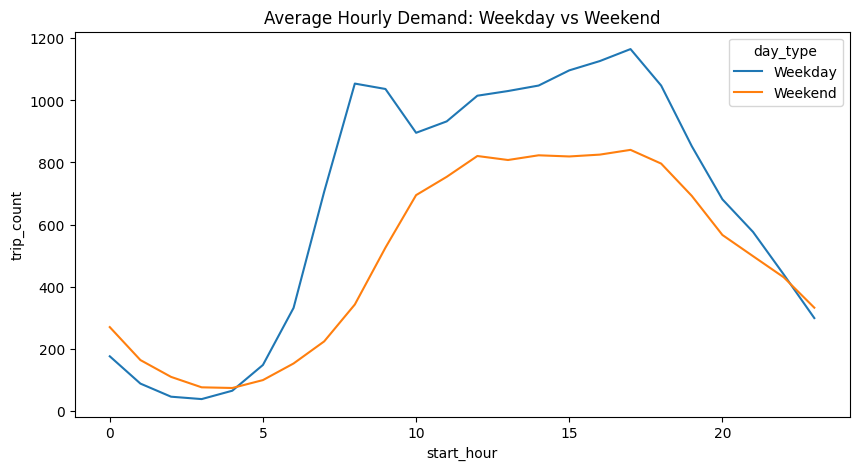

In [24]:
df["day_of_week"] = df["trip_start_timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"] >= 5

avg_demand_week = (
    df.groupby(["trip_start_hour", "is_weekend"])
      .size()
      .reset_index(name="trip_count")
)
avg_demand_week["start_hour"] = avg_demand_week["trip_start_hour"].dt.hour

avg_demand_week = avg_demand_week.groupby(["start_hour", "is_weekend"])["trip_count"].mean().reset_index()

avg_demand_week["day_type"] = avg_demand_week["is_weekend"].map({True: "Weekend", False: "Weekday"})

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_demand_week, x="start_hour", y="trip_count", hue="day_type")
plt.title("Average Hourly Demand: Weekday vs Weekend")